## Summary

This notebook implements a conditional normalizing flow in JAX to model $p(\text{dE/dx} | R)$.

**Key steps:**
1. Load edepsim segment data and extract (range, dE/dx) pairs.
2. Normalize and split into train/validation.
3. Define a simple affine coupling-based conditional flow.
4. Train with negative log-likelihood loss using JAX's autodiff and JIT.
5. Evaluate on validation set and sample from the learned distribution.
6. Visualize results: loss curves, empirical vs. sampled distributions, and 2D histograms.

**Next steps:**
- Refine the flow architecture (e.g., use masked autoencoders, more coupling layers).
- Experiment with different normalizations and data augmentation.
- Compute posterior predictive checks and calibration metrics.
- Save/load trained models for inference.

# Conditional Normalizing Flow: Range R → dE/dx Distribution

Fit a 2D histogram of (range R, dE/dx) using a conditional normalizing flow in JAX.
This model learns to output dE/dx distributions conditioned on a given residual range value.

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import h5py
import numpy as np
import jax
import jax.numpy as jnp
from jax import Array, jit, grad, vmap
from functools import partial
import matplotlib.pyplot as plt
from pathlib import Path

import equinox as eqx

if not hasattr(jax.random, 'KeyArray'):
    jax.random.KeyArray = Array

from flowjax.bijections import RationalQuadraticSpline
from flowjax.distributions import StandardNormal
from flowjax.flows import masked_autoregressive_flow

# Set random seed for reproducibility
rng_key = jax.random.PRNGKey(42)


/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.3 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
ERROR:2026-05-21 00:33:18,145:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 340, in initialize
    for _name, _value in cuda_plugin_extension.ffi_registrations().items():
AttributeError: module 'jax_cuda12_plugin.cuda_plugin_extension' has no attribute 'ffi_registrations'. Did you mean: 'registrations'?


## 1. Load Segment Data from HDF5

Load the edepsim output, extract segments, and fetch the range and dE/dx fields.

In [ ]:
# # stopping proton 0.1mm
# fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"
# tag = "stopping_proton_dx0.1mm"

# # stopping muon 0.1mm
# fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3543042/job_23756464_0000/output_23756464_0000-edepsim_lbl_range_0.05cm.h5"
# tag = "stopping_muon_dx0.1mm"

# # through-going muon 0.1mm
# fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3576201/job_23729838_0000/output_23729838_0000-edepsim_lbl_range_0.05cm.h5"
# tag = "throughgoing_muon_dx0.1mm"

with h5py.File(fname_lbl_01mm, 'r') as f:
    seg_lbl_01 = f['segments'][:]

# Extract range and dE/dx fields
range_data = seg_lbl_01['range']
dedx_data = seg_lbl_01['dEdx']

print(f"Loaded {len(range_data)} segments")
print(f"Range: min={range_data.min():.4f}, max={range_data.max():.4f}")
print(f"dE/dx: min={dedx_data.min():.4f}, max={dedx_data.max():.4f}")
print(f"Data shapes: range={range_data.shape}, dedx={dedx_data.shape}")

Loaded 33707212 segments
Range: min=-130.4596, max=-0.0500
dE/dx: min=0.1047, max=80.4546
Data shapes: range=(33707212,), dedx=(33707212,)


In [2]:
# Added loader for stopping_proton_dx0.1mm from wildcard job files (does not overwrite existing cells).
from glob import glob

tag = "stopping_proton_dx0.1mm"
pattern = (
    "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/"
    "production_3978808/job_*/output_*-edepsim_lbl_range_0.05cm.h5"
)
files = sorted(glob(pattern))

if not files:
    raise FileNotFoundError(f"No files matched pattern: {pattern}")

range_chunks = []
dedx_chunks = []
n_segments_total = 0

for fpath in files:
    with h5py.File(fpath, "r") as f:
        seg = f["segments"][:]
    range_chunks.append(seg["range"].astype(np.float32))
    dedx_chunks.append(seg["dEdx"].astype(np.float32))
    n_segments_total += seg.shape[0]

range_data = np.concatenate(range_chunks, axis=0)
dedx_data = np.concatenate(dedx_chunks, axis=0)

print(f"tag={tag}")
print(f"Matched files: {len(files)}")
print(f"Total segments read: {n_segments_total}")
print(f"range_data shape={range_data.shape}, min={range_data.min():.4f}, max={range_data.max():.4f}")
print(f"dedx_data shape={dedx_data.shape}, min={dedx_data.min():.4f}, max={dedx_data.max():.4f}")

tag=stopping_proton_dx0.1mm
Matched files: 50
Total segments read: 39205695
range_data shape=(39205695,), min=0.0500, max=57.7498
dedx_data shape=(39205695,), min=0.2055, max=13379.7715


## 2. Build R and dE/dx Training Arrays

Clean the data, remove invalid entries, and assemble paired training samples.

In [3]:
# Remove NaN and invalid values
mask = np.isfinite(range_data) & np.isfinite(dedx_data) & (range_data > 0) & (dedx_data > 0)

R_clean = range_data[mask].astype(np.float32)
dEdx_clean = dedx_data[mask].astype(np.float32)

print(f"After cleaning: {len(R_clean)} valid samples")
print(f"Range: min={R_clean.min():.4f}, max={R_clean.max():.4f}")
print(f"dE/dx: min={dEdx_clean.min():.4f}, max={dEdx_clean.max():.4f}")

# Assemble paired training samples
data_pairs = np.column_stack([R_clean, dEdx_clean])
print(f"Training data shape: {data_pairs.shape}")

After cleaning: 39205695 valid samples
Range: min=0.0500, max=57.7498
dE/dx: min=0.2055, max=13379.7715
Training data shape: (39205695, 2)


## 3. Normalize Variables and Split Train/Validation Sets

Standardize R and dE/dx, then split into training and validation subsets.

In [4]:
# Compute normalization statistics
R_mean, R_std = R_clean.mean(), R_clean.std()

# Train in log-space to enforce strictly positive physical dE/dx at inference.
eps = 1e-8
dEdx_log = np.log(dEdx_clean + eps)
dEdx_mean, dEdx_std = dEdx_log.mean(), dEdx_log.std()

print("Normalization stats:")
print(f"  R: mean={R_mean:.4f}, std={R_std:.4f}")
print(f"  log(dEdx): mean={dEdx_mean:.4f}, std={dEdx_std:.4f}")

# Normalize data: [R_norm, log(dEdx)_norm]
data_normalized = data_pairs.copy()
data_normalized[:, 0] = (R_clean - R_mean) / R_std
data_normalized[:, 1] = (dEdx_log - dEdx_mean) / dEdx_std

# Split into train/validation
n_total = len(data_normalized)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

# Shuffle
perm = np.random.permutation(n_total)
data_normalized = data_normalized[perm]

data_train = data_normalized[:n_train]
data_val = data_normalized[n_train:]

print(f"Train: {n_train}, Validation: {n_val}")

# Store normalization params for later use
norm_params = {
    'R_mean': R_mean,
    'R_std': R_std,
    'dEdx_log_mean': dEdx_mean,
    'dEdx_log_std': dEdx_std,
    'dEdx_eps': eps,
}

Normalization stats:
  R: mean=7.4482, std=6.4474
  log(dEdx): mean=2.1795, std=0.5974
Train: 31364556, Validation: 7841139


## 4. Define the Conditional Normalizing Flow in JAX

Implement a simple conditional flow: $p(y|x) = p_0(z) \left|\frac{dz}{dy}\right|$, where $z = T_\theta(y; x)$.

In [5]:
def make_flow(key, hidden_dim=64, n_layers=3):

    flow = masked_autoregressive_flow(
        key=key,
        base_dist=StandardNormal((1,)),
        transformer=RationalQuadraticSpline(knots=8, interval=5.0),
        cond_dim=1,
        flow_layers=6,
        nn_width=hidden_dim,
        nn_depth=n_layers,
        # invert=True,
    )
    return flow

def make_flow_params(key, hidden_dim=64, n_layers=3):
    """Initialize parameters for a simple conditional neural network transform."""
    keys = jax.random.split(key, 2 * n_layers + 1)
    params = {}
    
    # Layers: condition_embedding -> hidden layers -> output
    # Embedding layer: (condition) -> hidden_dim
    params['embed_w'] = jax.random.normal(keys[0], (1, hidden_dim)) * 0.01
    params['embed_b'] = jnp.zeros(hidden_dim)
    
    # Hidden layers: each takes (hidden_dim + input_dim) and outputs hidden_dim
    for i in range(n_layers):
        in_dim = hidden_dim
        # in_dim = hidden_dim + 1 if i == 0 else hidden_dim
        params[f'w{i}'] = jax.random.normal(keys[i+1], (in_dim, hidden_dim)) * 0.01
        params[f'b{i}'] = jnp.zeros(hidden_dim)
    
    # Output layer: maps to (scale, shift) for affine coupling
    params['w_out'] = jax.random.normal(keys[-1], (hidden_dim, 2)) * 0.01
    params['b_out'] = jnp.zeros(2)
    
    return params

def affine_coupling_forward(y, condition, params, key):
    """Simple affine coupling: z = scale * y + shift, with scale, shift conditioned on x."""
    # Embed condition
    h = jnp.tanh(jnp.dot(jnp.array([[condition]]), params['embed_w']) + params['embed_b']).squeeze()
    x = h
    for i in range(3):
        x = jnp.tanh(jnp.dot(x, params[f'w{i}']) + params[f'b{i}'])
    scale_shift = jnp.dot(x, params['w_out']) + params['b_out']
    log_scale, shift = scale_shift[0], scale_shift[1]
    scale = jnp.exp(jnp.clip(log_scale, -3, 3))
    return scale * y + shift, log_scale

def affine_coupling_inverse(z, condition, params, key):
    h = jnp.tanh(jnp.dot(jnp.array([[condition]]), params['embed_w']) + params['embed_b']).squeeze()
    x = h
    for i in range(3):
        x = jnp.tanh(jnp.dot(x, params[f'w{i}']) + params[f'b{i}'])
    scale_shift = jnp.dot(x, params['w_out']) + params['b_out']
    log_scale, shift = scale_shift[0], scale_shift[1]
    scale = jnp.exp(jnp.clip(log_scale, -3, 3))
    return (z - shift) / scale

def standard_normal_logpdf(z):
    """Log-density of standard normal."""
    return -0.5 * (z**2 + jnp.log(2 * jnp.pi))

print("Flow architecture defined.")

Flow architecture defined.


## 5. Create the Log-Likelihood Loss and Training Step

Negative log-likelihood for conditional density estimation with JIT and autodiff.

In [6]:
def nll_loss_single(y, condition, flow, params, key, flow_type='flowjax'):
    if flow_type == 'flowjax':
        del flow, key
        log_py = params.log_prob(jnp.atleast_1d(y), condition=jnp.atleast_1d(condition))
        return -log_py
    else:
        z, log_det_jac = affine_coupling_forward(y, condition, params, key)
        log_pz = standard_normal_logpdf(z)
        log_py = log_pz + log_det_jac
        return -log_py


def nll_loss_batch(batch, flow, key, flow_type='flowjax'):
    conditions = batch[:, 0]
    ys = batch[:, 1]
    if flow_type == 'flowjax':
        log_py = flow.log_prob(ys[:, None], condition=conditions[:, None])
        return -jnp.mean(log_py)
    else:
        keys = jax.random.split(key, len(batch))
        losses = vmap(lambda c, y, k: nll_loss_single(y, c, flow, flow, k, flow_type))(conditions, ys, keys)
        return jnp.mean(losses)

print("Loss and training functions defined.")

Loss and training functions defined.


## 6. Train the Model with JIT and Optimizer State

Run the training loop with Adam optimizer, track losses, and save best model.

In [7]:
import optax

flow_type = 'flowjax'  # flowjax or affine

# Initialize model and optimizer (self-contained training cell)
rng_key, subkey = jax.random.split(rng_key)
if flow_type == 'flowjax':
    model = make_flow(subkey)
else:
    model = make_flow_params(subkey, hidden_dim=64, n_layers=3)

# Training configuration
n_epochs = 50
batch_size = 16384
#batch_size = 4096

# Keep datasets on CPU as float32; move only the active batch to JAX/GPU.
data_train_cpu = np.asarray(data_train, dtype=np.float32)
data_val_cpu = np.asarray(data_val, dtype=np.float32)
n_batches = int(np.ceil(len(data_train_cpu) / batch_size))

# Learning-rate scheduler: linear warmup + cosine decay
lr_peak = 1e-3
lr_end = 1e-5
warmup_epochs = 5
warmup_steps = max(1, warmup_epochs * n_batches)
decay_steps = max(1, (n_epochs - warmup_epochs) * n_batches)
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=lr_peak,
    warmup_steps=warmup_steps,
    decay_steps=decay_steps,
    end_value=lr_end,
)
optimizer = optax.adam(lr_schedule)
optimizer_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array) if flow_type == 'flowjax' else model)

train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
best_params = jax.tree_util.tree_map(lambda x: jnp.array(x) if eqx.is_inexact_array(x) else x, model)

val_loss_fn = eqx.filter_jit(lambda f, batch, key: nll_loss_batch(batch, f, key, flow_type))

def to_device_batch(batch_cpu):
    return jnp.asarray(batch_cpu, dtype=jnp.float32)

def eval_loss_cpu(model, data_cpu, rng_key, batch_size):
    total_loss = 0.0
    total_examples = 0
    for start in range(0, len(data_cpu), batch_size):
        stop = min(start + batch_size, len(data_cpu))
        batch_cpu = data_cpu[start:stop]
        batch = to_device_batch(batch_cpu)
        rng_key, subkey = jax.random.split(rng_key)
        batch_loss = float(val_loss_fn(model, batch, subkey))
        total_loss += batch_loss * len(batch_cpu)
        total_examples += len(batch_cpu)
    return total_loss / total_examples, rng_key

if flow_type == 'flowjax':
    @eqx.filter_jit
    def train_step_impl(batch, model, optimizer_state, key):
        def loss_fn(f):
            return nll_loss_batch(batch, f, key, flow_type)
        
        loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
        updates, new_opt_state = optimizer.update(
            grads,
            optimizer_state,
            eqx.filter(model, eqx.is_inexact_array)
        )
        new_model = eqx.apply_updates(model, updates)
        return loss, new_model, new_opt_state
else:
    @jax.jit
    def train_step_impl(batch, model, optimizer_state, key):
        loss_fn = lambda f: nll_loss_batch(batch, f, key, flow_type)
        loss, grads = jax.value_and_grad(loss_fn)(model)
        updates, new_opt_state = optimizer.update(grads, optimizer_state, model)
        new_model = optax.apply_updates(model, updates)
        return loss, new_model, new_opt_state

print("Starting training...")
global_step = 0
for epoch in range(n_epochs):
    rng_key, subkey = jax.random.split(rng_key)
    epoch_seed = int(jax.random.randint(subkey, (), 0, np.iinfo(np.int32).max))
    perm = np.random.default_rng(epoch_seed).permutation(len(data_train_cpu))

    epoch_losses = []
    epoch_lrs = []
    for i in range(n_batches):
        batch_indices = perm[i * batch_size : min((i + 1) * batch_size, len(data_train_cpu))]
        batch_cpu = data_train_cpu[batch_indices]
        batch = to_device_batch(batch_cpu)
        rng_key, subkey = jax.random.split(rng_key)
        loss, model, optimizer_state = train_step_impl(batch, model, optimizer_state, subkey)
        epoch_losses.append(float(loss))

        current_lr = float(lr_schedule(global_step))
        epoch_lrs.append(current_lr)
        lr_history.append(current_lr)
        global_step += 1

    train_epoch_loss = float(np.mean(epoch_losses))
    if jnp.isnan(train_epoch_loss):
        print(f"NaN at epoch {epoch + 1}, stopping")
        break

    val_loss, rng_key = eval_loss_cpu(model, data_val_cpu, rng_key, batch_size)

    train_losses.append(train_epoch_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params = jax.tree_util.tree_map(lambda x: x.copy() if hasattr(x, 'copy') else x, model)

    if (epoch + 1) % 5 == 0:
        epoch_lr = float(np.mean(epoch_lrs)) if len(epoch_lrs) else float(lr_schedule(global_step))
        print(f"Epoch {epoch + 1}: train={train_epoch_loss:.4f}, val={val_loss:.4f}, lr={epoch_lr:.2e}")

# Keep the trained model available for later notebook cells.
flow = model

print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Starting training...


2026-05-21 00:34:03.231130: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-21 00:34:03.231282: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Epoch 5: train=0.3688, val=0.3671, lr=9.00e-04
Epoch 10: train=0.3658, val=0.3650, lr=9.69e-04
Epoch 15: train=0.3648, val=0.3639, lr=8.68e-04
Epoch 20: train=0.3645, val=0.3647, lr=7.12e-04
Epoch 25: train=0.3642, val=0.3646, lr=5.24e-04
Epoch 30: train=0.3639, val=0.3638, lr=3.34e-04
Epoch 35: train=0.3636, val=0.3645, lr=1.69e-04
Epoch 40: train=0.3635, val=0.3636, lr=5.56e-05
Epoch 45: train=0.3634, val=0.3636, lr=1.05e-05
Epoch 50: train=0.3634, val=0.3635, lr=1.00e-05
Training complete. Best val loss: 0.3635


## 7. Evaluate Conditional Density Quality

Compare learned vs. empirical distributions on validation bins.

In [8]:
# Evaluate on validation set in physical units
R_val_phys = data_val[:, 0] * float(R_std) + float(R_mean)
dEdx_val_phys = np.exp(data_val[:, 1] * float(dEdx_std) + float(dEdx_mean))

n_bins_condition = 5
R_edges = np.linspace(R_val_phys.min(), R_val_phys.max(), n_bins_condition + 1)

print("Validation set statistics by physical R bin:")
print(f"{'R bin [cm]':<30} {'Empirical dE/dx':<20} {'Count':<10}")

empirical_stats = {}
for i in range(n_bins_condition):
    mask = (R_val_phys >= R_edges[i]) & (R_val_phys < R_edges[i + 1])
    if mask.sum() > 0:
        empirical_mean = dEdx_val_phys[mask].mean()
        count = int(mask.sum())
        empirical_stats[i] = (float(empirical_mean), count)
        print(f"[{R_edges[i]:.3f}, {R_edges[i+1]:.3f}]  {empirical_mean:.6f}  {count}")

print("\nEvaluation complete.")

Validation set statistics by physical R bin:
R bin [cm]                     Empirical dE/dx      Count     
[0.050, 11.586]  12.394124  6036156
[11.586, 23.122]  5.519187  1598043
[23.122, 34.658]  4.444577  195375
[34.658, 46.194]  3.873742  11022
[46.194, 57.730]  3.507325  542

Evaluation complete.


## 8. Sample dE/dx Distributions at Fixed R Values

Generate samples from the learned conditional flow at selected R values.

In [9]:
def _ensure_typed_key(key):
    """Convert legacy uint32 PRNGKey to new typed key when required by FlowJAX/JAX."""
    if not hasattr(jax.random, "key"):
        return key

    try:
        if jax.dtypes.issubdtype(key.dtype, jax.dtypes.prng_key):
            return key
    except Exception:
        pass

    # Legacy key path: derive a stable seed from raw uint32 key data.
    key_data = np.asarray(key, dtype=np.uint32).reshape(-1)
    if key_data.size >= 2:
        seed64 = (np.uint64(key_data[0]) << np.uint64(32)) ^ np.uint64(key_data[1])
    elif key_data.size == 1:
        seed64 = np.uint64(key_data[0])
    else:
        seed64 = np.uint64(0)
    seed = int(seed64 % np.uint64(np.iinfo(np.uint32).max))
    return jax.random.key(seed)


def sample_conditional(condition_normalized, n_samples, params, key, flow=None, flow_type='flowjax'):
    key = _ensure_typed_key(key)
    conditions = jnp.asarray(condition_normalized, dtype=jnp.float32)

    if flow_type == 'flowjax':
        # Scalar condition -> sample n_samples from one conditional distribution.
        if conditions.ndim == 0:
            condition_1d = jnp.asarray([conditions], dtype=jnp.float32)  # shape (1,)
            samples = flow.sample(key, sample_shape=(n_samples,), condition=condition_1d)
            return jnp.asarray(samples).reshape(-1)

        # Vector conditions -> sample one value per condition.
        conditions = conditions.reshape(-1)
        if int(conditions.shape[0]) != int(n_samples):
            raise ValueError(
                f"For batched conditions, n_samples must equal len(condition_normalized). "
                f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
            )
        condition_2d = conditions[:, None]  # shape (N, 1)
        samples = flow.sample(key, sample_shape=(), condition=condition_2d)
        return jnp.asarray(samples).reshape(-1)
    else:
        if conditions.ndim == 0:
            conditions = jnp.full((n_samples,), conditions, dtype=jnp.float32)
        else:
            conditions = conditions.reshape(-1)
            if int(conditions.shape[0]) != int(n_samples):
                raise ValueError(
                    f"For batched conditions, n_samples must equal len(condition_normalized). "
                    f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
                )
        keys = jax.random.split(key, n_samples)
        z_samples = jax.random.normal(key, (n_samples,), dtype=jnp.float32)
        return vmap(
            lambda z, c, k: affine_coupling_inverse(z, c, params, k)
        )(z_samples, conditions, keys)

# Choose physical-R values, then normalize for conditioning the flow.
R_test_values_phys = np.linspace(float(R_clean.min()), float(R_clean.max()), 3)
R_test_values_norm = (R_test_values_phys - float(R_mean)) / float(R_std)
n_samples_per_R = 1000

eps = float(norm_params.get('dEdx_eps', 1e-8))

rng_key, subkey = jax.random.split(rng_key)

sampled_distributions = {}
for R_phys, R_norm in zip(R_test_values_phys, R_test_values_norm):
    rng_key, subkey = jax.random.split(rng_key)

    # Model output is normalized log(dE/dx).
    samples_norm = sample_conditional(float(R_norm), n_samples_per_R, best_params, subkey, flow=flow, flow_type=flow_type)

    # Convert prediction back to physical dE/dx: exp(log dE/dx).
    samples_log = np.array(samples_norm) * float(dEdx_std) + float(dEdx_mean)
    samples_phys = np.exp(samples_log) - eps
    samples_phys = np.clip(samples_phys, 0.0, None)

    sampled_distributions[float(R_phys)] = samples_phys
    print(
        f"Sampled {n_samples_per_R} dE/dx values for R={R_phys:.4f} cm "
        f"(norm={R_norm:.4f}): mean={samples_phys.mean():.4f}, std={samples_phys.std():.4f}, "
        f"min={samples_phys.min():.4f}"
    )

print("Sampling complete.")

2026-05-21 00:51:17.689075: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-21 00:51:17.689120: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Sampled 1000 dE/dx values for R=0.0500 cm (norm=-1.1475): mean=65.1623, std=3.1372, min=52.8077
Sampled 1000 dE/dx values for R=28.8999 cm (norm=3.3272): mean=4.2342, std=2.6696, min=1.9829
Sampled 1000 dE/dx values for R=57.7498 cm (norm=7.8018): mean=3.2594, std=2.1001, min=1.4295
Sampling complete.


## 9. Visualize Learned and True Distributions

Plot 2D histogram, loss curves, and conditional slices.

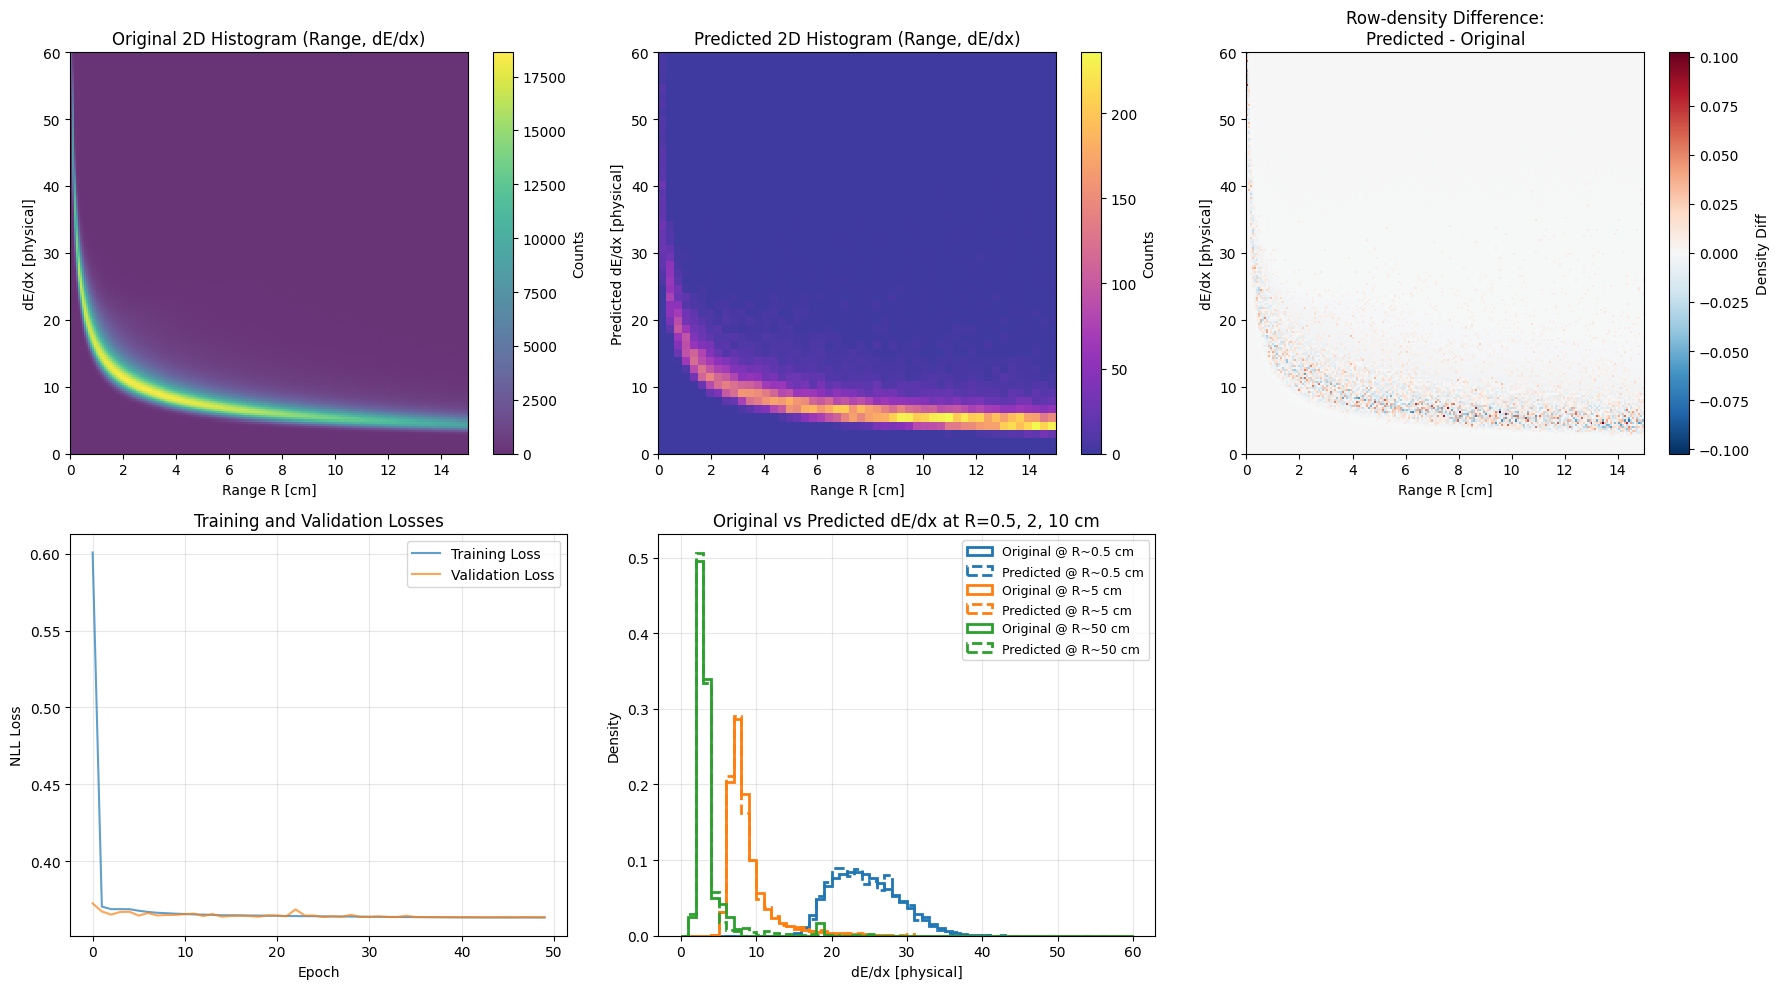

Visualization complete.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Original 2D histogram in physical units
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
h0 = ax.hist2d(R_clean, dEdx_clean, bins=[200,200], range=[[0,15], [0,60]], cmap='viridis', alpha=0.8)
ax.set_xlabel('Range R [cm]')
ax.set_ylabel('dE/dx [physical]')
ax.set_title('Original 2D Histogram (Range, dE/dx)')
plt.colorbar(h0[3], ax=ax, label='Counts')
h0_xedges = h0[1]
h0_yedges = h0[2]
h0_counts = h0[0]

# 2. 2D histogram of predicted (R, dE/dx) from the model
ax = axes[0, 1]
n_pred_samples = 100000
R_pred_phys = np.random.uniform(R_clean.min(), R_clean.max(), n_pred_samples)
R_pred_norm = (R_pred_phys - float(R_mean)) / float(R_std)
rng_key_pred = rng_key
pred_dedx_phys = []
batch_size = 1000
for i in range(0, n_pred_samples, batch_size):
    this_batch = R_pred_norm[i:i+batch_size]
    rng_key_pred, subkey = jax.random.split(rng_key_pred)
    samples_norm = sample_conditional(this_batch, len(this_batch), best_params, subkey, flow=flow, flow_type=flow_type)
    samples_log = np.array(samples_norm) * float(dEdx_std) + float(dEdx_mean)
    samples_phys = np.exp(samples_log) - float(norm_params.get('dEdx_eps', 1e-8))
    samples_phys = np.clip(samples_phys, 0.0, None)
    pred_dedx_phys.append(samples_phys)
pred_dedx_phys = np.concatenate(pred_dedx_phys)
h1 = ax.hist2d(R_pred_phys, pred_dedx_phys, bins=50, range=[[0,15], [0,60]], cmap='plasma', alpha=0.8)
ax.set_xlabel('Range R [cm]')
ax.set_ylabel('Predicted dE/dx [physical]')
ax.set_title('Predicted 2D Histogram (Range, dE/dx)')
plt.colorbar(h1[3], ax=ax, label='Counts')
h1_counts = h1[0]

# 3. Row-normalized difference: predicted density - original density
ax = axes[0, 2]
h_orig_diff, _, _ = np.histogram2d(R_clean, dEdx_clean, bins=[h0_xedges, h0_yedges])
h_pred_diff, _, _ = np.histogram2d(R_pred_phys, pred_dedx_phys, bins=[h0_xedges, h0_yedges])

def normalize_rows_to_density(h):
    row_sum = h.sum(axis=1, keepdims=True)
    h_norm = np.divide(h, row_sum, out=np.zeros_like(h, dtype=float), where=row_sum > 0)
    return h_norm

h_orig_row_density = normalize_rows_to_density(h_orig_diff)
h_pred_row_density = normalize_rows_to_density(h_pred_diff)
h_row_density_diff = h_pred_row_density - h_orig_row_density

vmax = np.max(np.abs(h_row_density_diff))
if vmax == 0:
    vmax = 1.0

im = ax.pcolormesh(
    h0_xedges,
    h0_yedges,
    h_row_density_diff.T,
    cmap='RdBu_r',
    shading='auto',
    vmin=-vmax,
    vmax=vmax,
)
ax.set_xlabel('Range R [cm]')
ax.set_ylabel('dE/dx [physical]')
ax.set_title('Row-density Difference:\nPredicted - Original')
plt.colorbar(im, ax=ax, label='Density Diff')

# 4. Training and validation loss curves
ax = axes[1, 0]
ax.plot(train_losses, label='Training Loss', alpha=0.7)
ax.plot(val_losses, label='Validation Loss', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('NLL Loss')
ax.set_title('Training and Validation Losses')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. 1D dE/dx comparisons at selected R bins
ax = axes[1, 1]
R_targets = [0.5, 5.0, 50.0]
# R_targets = [0.5, 2.0, 10.0]
R_half_width = 0.25
colors = ['tab:blue', 'tab:orange', 'tab:green']

for R_tgt, color in zip(R_targets, colors):
    r_lo, r_hi = R_tgt - R_half_width, R_tgt + R_half_width

    mask_orig = (R_clean >= r_lo) & (R_clean < r_hi)
    mask_pred = (R_pred_phys >= r_lo) & (R_pred_phys < r_hi)

    orig_slice = dEdx_clean[mask_orig]
    pred_slice = pred_dedx_phys[mask_pred]

    if len(orig_slice) > 10 and len(pred_slice) > 10:
        ax.hist(
            orig_slice,
            bins=60,
            range=[0, 60],
            density=True,
            histtype='step',
            linewidth=2.0,
            color=color,
            linestyle='-',
            label=f'Original @ R~{R_tgt:g} cm'
        )
        ax.hist(
            pred_slice,
            bins=60,
            range=[0, 60],
            density=True,
            histtype='step',
            linewidth=2.0,
            color=color,
            linestyle='--',
            label=f'Predicted @ R~{R_tgt:g} cm'
        )

ax.set_xlabel('dE/dx [physical]')
ax.set_ylabel('Density')
ax.set_title('Original vs Predicted dE/dx at R=0.5, 2, 10 cm')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Hide the extra subplot
ax_empty = axes[1, 2]
ax_empty.axis('off')

plt.tight_layout()
plt.show()

print("Visualization complete.")

In [11]:
# Save the trained model for use in quenching_jax.py
import pickle
from pathlib import Path
import numpy as np
import equinox as eqx

# Create output directory if it doesn't exist
model_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
model_dir.mkdir(exist_ok=True)

# Use Equinox leaf serialization for FlowJAX/Equinox models (pickle alone fails)
model_state_path = model_dir / f"dedx_flow_model_{tag}.eqx"
model_meta_path = model_dir / f"dedx_flow_model_meta_{tag}.pkl"
norm_params_path = model_dir / f"dedx_norm_params_{tag}.pkl"

# Serialize model leaves
eqx.tree_serialise_leaves(model_state_path, best_params)

# Store lightweight metadata separately
norm_params_serializable = {
    k: float(v) if isinstance(v, (np.floating, float, int)) else v
    for k, v in norm_params.items()
}

model_meta = {
    "flow_type": flow_type,
    "model_state_file": model_state_path.name,
    "norm_params": norm_params_serializable,
    "load_note": (
        "Rebuild a template flow with the same architecture, then call "
        "eqx.tree_deserialise_leaves(model_state_path, template_flow)."
    ),
}

with open(model_meta_path, "wb") as f:
    pickle.dump(model_meta, f)

# Optional standalone norm params file for compatibility with older scripts
with open(norm_params_path, "wb") as f:
    pickle.dump(norm_params_serializable, f)

print(f"Model state saved to {model_state_path}")
print(f"Model metadata saved to {model_meta_path}")
print(f"Normalization parameters saved to {norm_params_path}")
print(f"Model type: {flow_type}")
print("Normalization stats:")
print(f"  R: mean={norm_params_serializable['R_mean']:.4f}, std={norm_params_serializable['R_std']:.4f}")
print(
    f"  log(dEdx): mean={norm_params_serializable['dEdx_log_mean']:.4f}, "
    f"std={norm_params_serializable['dEdx_log_std']:.4f}"
)

Model state saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_stopping_proton_dx0.1mm.eqx
Model metadata saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_meta_stopping_proton_dx0.1mm.pkl
Normalization parameters saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_norm_params_stopping_proton_dx0.1mm.pkl
Model type: flowjax
Normalization stats:
  R: mean=7.4482, std=6.4474
  log(dEdx): mean=2.1795, std=0.5974


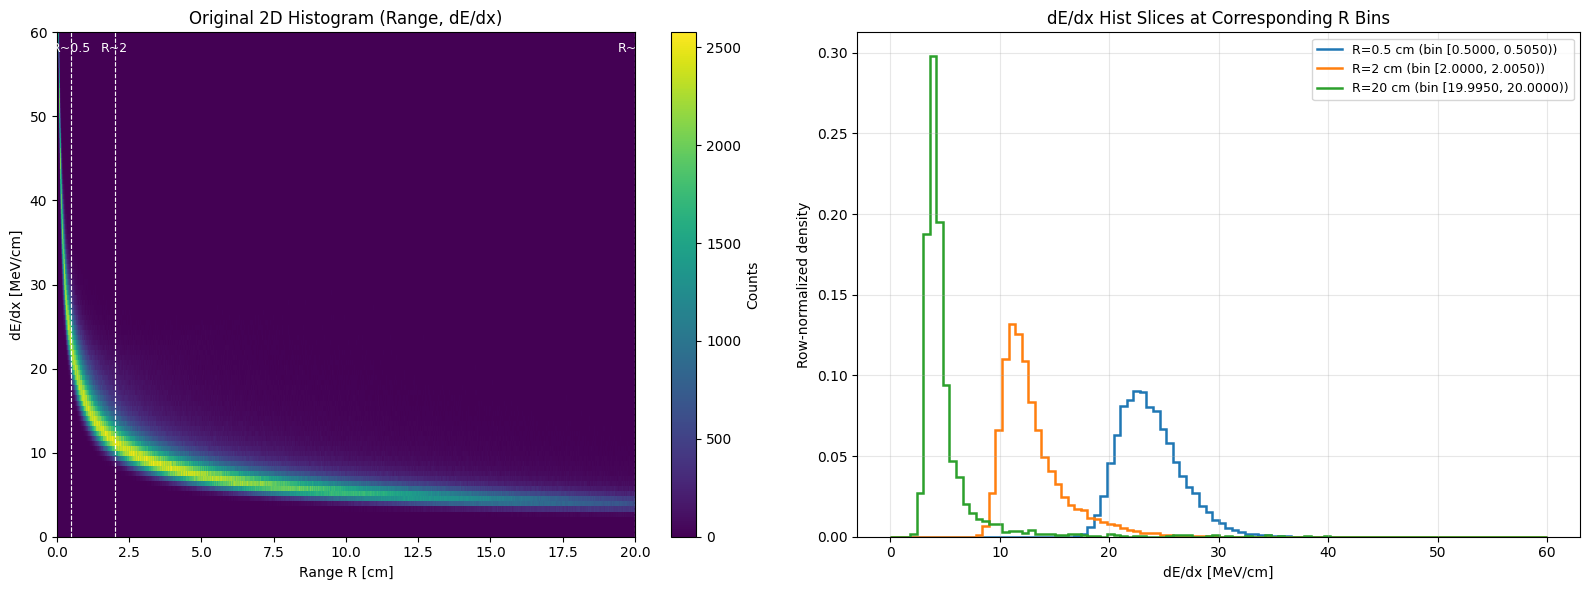

Saved 2D dE/dx histogram to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_proton_dx0.1mm.npz
counts shape=(4000, 100), r_bins=4000, dedx_bins=100
  slice R=0.5 cm -> bin 100, interval [0.500000, 0.505000)
  slice R=2 cm -> bin 400, interval [2.000000, 2.005000)
  slice R=20 cm -> bin 3999, interval [19.995000, 20.000000)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Build 2D histogram directly (same binning/range as before)
r_bins = 4000
dedx_bins = 100

r_range = (0.0, 20.0)
dedx_range = (0.0, 60.0)

# r_range = (0.0, 80.0)
# dedx_range = (0.0, 15.0)

# r_range = (0.0, 80.0)
# dedx_range = (0.0, 10.0)

h_counts, r_edges, dedx_edges = np.histogram2d(
    R_clean,
    dEdx_clean,
    bins=[r_bins, dedx_bins],
    range=[r_range, dedx_range],
)

# Prepare centers for slice plotting
dedx_centers = 0.5 * (dedx_edges[:-1] + dedx_edges[1:])

# Target R values and corresponding histogram row indices
slice_targets = np.array([0.5, 2.0, 20.0], dtype=np.float32)
# slice_targets = np.array([0.5, 5.0, 50.0], dtype=np.float32)
slice_bin_indices = np.clip(
    np.searchsorted(r_edges, slice_targets, side="right") - 1,
    0,
    len(r_edges) - 2,
)

# Figure with 2 panels: 2D histogram + row slices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: 2D histogram
ax0 = axes[0]
mesh = ax0.pcolormesh(
    r_edges,
    dedx_edges,
    h_counts.T,
    shading="auto",
    cmap="viridis",
)
ax0.set_xlabel("Range R [cm]")
ax0.set_ylabel("dE/dx [MeV/cm]")
ax0.set_title("Original 2D Histogram (Range, dE/dx)")
plt.colorbar(mesh, ax=ax0, label="Counts")

# Mark selected R bins on the 2D panel
for t, idx in zip(slice_targets, slice_bin_indices):
    r_left = r_edges[idx]
    r_right = r_edges[idx + 1]
    ax0.axvline(r_left, color="w", linestyle="--", linewidth=0.8, alpha=0.8)
    ax0.axvline(r_right, color="w", linestyle="--", linewidth=0.8, alpha=0.8)
    ax0.text(
        0.5 * (r_left + r_right),
        dedx_range[1] * 0.98,
        f"R~{t:g}",
        color="w",
        fontsize=9,
        ha="center",
        va="top",
    )

# Right: dE/dx slices at corresponding R bins (row-normalized histograms)
ax1 = axes[1]
slice_rows_density = []
for t, idx in zip(slice_targets, slice_bin_indices):
    row_counts = h_counts[idx, :]
    row_sum = row_counts.sum()
    if row_sum > 0:
        row_density = row_counts / row_sum
    else:
        row_density = np.zeros_like(row_counts)

    slice_rows_density.append(row_density.astype(np.float32))

    r_left = r_edges[idx]
    r_right = r_edges[idx + 1]
    ax1.stairs(
        row_density,
        dedx_edges,
        linewidth=1.8,
        label=f"R={t:g} cm (bin [{r_left:.4f}, {r_right:.4f}))",
    )

ax1.set_xlabel("dE/dx [MeV/cm]")
ax1.set_ylabel("Row-normalized density")
ax1.set_title("dE/dx Hist Slices at Corresponding R Bins")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Persist histogram artifact for quenching_jax.py lookup-based dE/dx density.
hist_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
hist_dir.mkdir(exist_ok=True)
hist_path = hist_dir / f"dedx_hist2d_{tag}.npz"

np.savez(
    hist_path,
    counts=h_counts.astype(np.float32),
    r_edges=r_edges.astype(np.float32),
    dedx_edges=dedx_edges.astype(np.float32),
    slice_targets_cm=slice_targets.astype(np.float32),
    slice_bin_indices=slice_bin_indices.astype(np.int32),
    slice_rows_density=np.asarray(slice_rows_density, dtype=np.float32),
)

print(f"Saved 2D dE/dx histogram to {hist_path}")
print(f"counts shape={h_counts.shape}, r_bins={len(r_edges)-1}, dedx_bins={len(dedx_edges)-1}")
for t, idx in zip(slice_targets, slice_bin_indices):
    print(f"  slice R={t:g} cm -> bin {idx}, interval [{r_edges[idx]:.6f}, {r_edges[idx+1]:.6f})")

Saved 1D marginal dE/dx histogram to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist1d_throughgoing_muon_dx0.1mm.npz
counts shape=(100,), dedx_bins=100
Total counts: 32930834.0


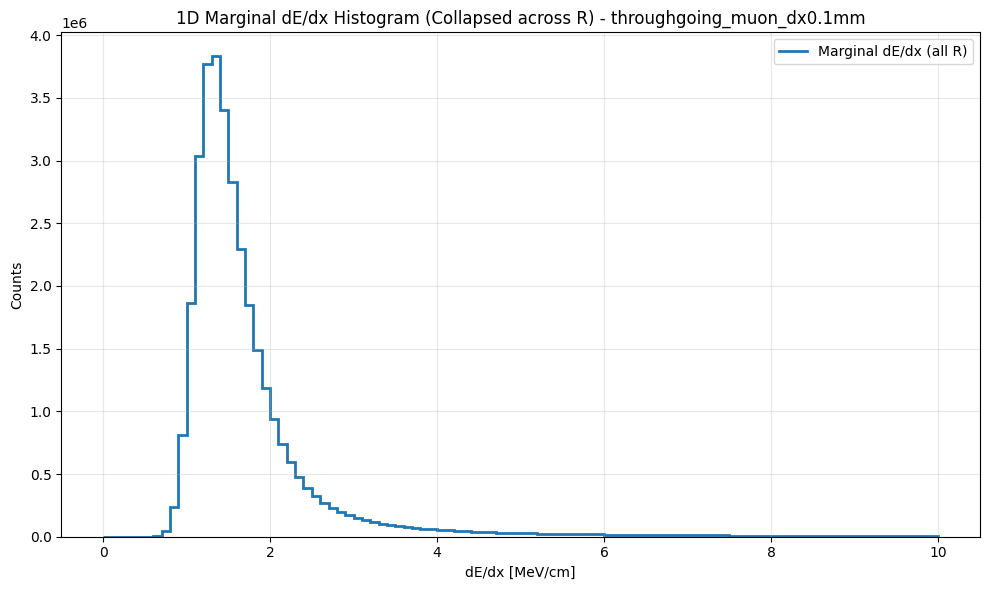

1D histogram storage complete.


In [7]:
import numpy as np
from pathlib import Path

# Compute 1D marginal dE/dx histogram (collapsed across all R)
# Use the same dedx_edges from the 2D histogram for consistency
dedx_1d_counts = h_counts.sum(axis=0)  # Sum over all R bins

# Prepare output directory
hist_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
hist_dir.mkdir(exist_ok=True)

# Save 1D marginal dE/dx histogram as separate artifact
hist_1d_path = hist_dir / f"dedx_hist1d_{tag}.npz"

np.savez(
    hist_1d_path,
    counts=dedx_1d_counts.astype(np.float32),
    dedx_edges=dedx_edges.astype(np.float32),
)

print(f"Saved 1D marginal dE/dx histogram to {hist_1d_path}")
print(f"counts shape={dedx_1d_counts.shape}, dedx_bins={len(dedx_edges)-1}")
print(f"Total counts: {dedx_1d_counts.sum()}")

# Also plot the 1D marginal for visual reference
fig, ax = plt.subplots(figsize=(10, 6))
ax.stairs(
    dedx_1d_counts,
    dedx_edges,
    linewidth=2.0,
    color="tab:blue",
    label="Marginal dE/dx (all R)",
)
ax.set_xlabel("dE/dx [MeV/cm]")
ax.set_ylabel("Counts")
ax.set_title(f"1D Marginal dE/dx Histogram (Collapsed across R) - {tag}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("1D histogram storage complete.")


In [63]:
!nvidia-smi

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Mon May 18 15:16:03 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  | 00000000:C1:00.0 Off |                    0 |
| N/A   31C    P0              55W / 400W |    534MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [64]:
!nvidia-smi --query-gpu=name,memory.total,memory.used,memory.free --format=csv

name, memory.total [MiB], memory.used [MiB], memory.free [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 534 MiB, 39805 MiB


NPZ counts shape: (4000, 100), total=37092440
H5 counts shape:  (4000, 100), total=3642451
Input segments in H5: 3653236


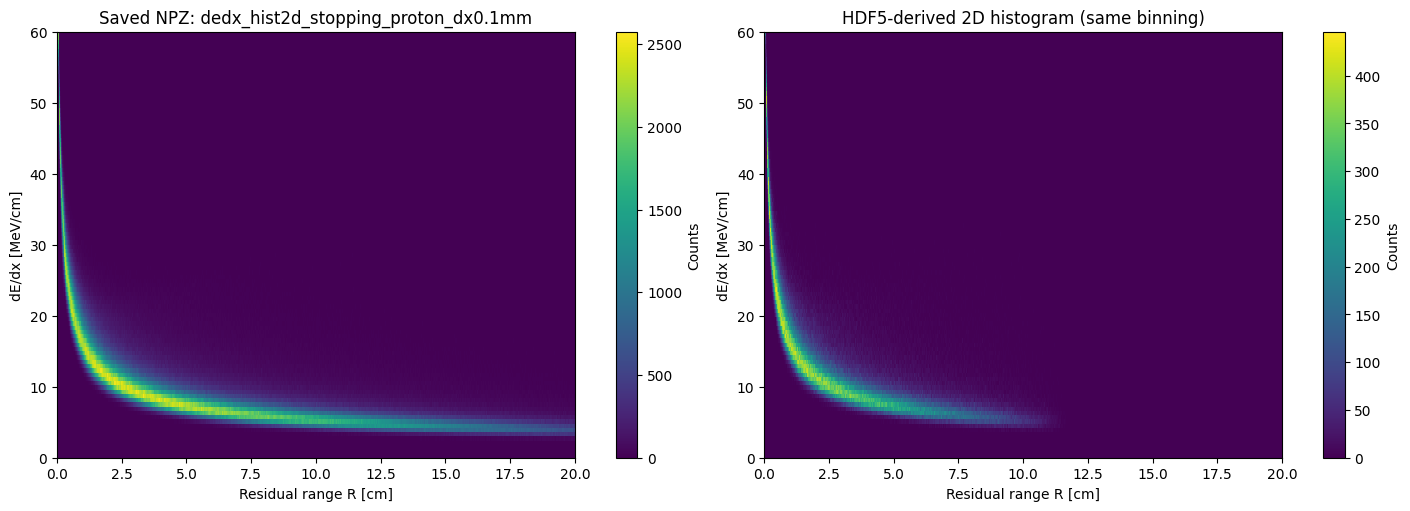

In [1]:
# Debug plot: compare saved stopping-proton histogram artifact vs source HDF5 segments side by side.
import numpy as np
import h5py
import matplotlib.pyplot as plt

npz_path = "/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_proton_dx0.1mm.npz"
h5_path = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"

# Load saved histogram artifact.
artifact = np.load(npz_path)
artifact_counts = np.asarray(artifact["counts"], dtype=np.float32)
r_edges = np.asarray(artifact["r_edges"], dtype=np.float32)
dedx_key = "dedx_edges" if "dedx_edges" in artifact.files else "dedex_edges"
dedx_edges = np.asarray(artifact[dedx_key], dtype=np.float32)

# Load raw HDF5 segments and make a histogram with exactly the same bin edges.
with h5py.File(h5_path, "r") as f:
    seg = f["segments"][:]
range_h5 = np.asarray(seg["range"], dtype=np.float32)
dedx_h5 = np.asarray(seg["dEdx"], dtype=np.float32)

h5_counts, _, _ = np.histogram2d(range_h5, dedx_h5, bins=[r_edges, dedx_edges])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

m0 = axes[0].pcolormesh(r_edges, dedx_edges, artifact_counts.T, shading="auto", cmap="viridis")
axes[0].set_title("Saved NPZ: dedx_hist2d_stopping_proton_dx0.1mm")
axes[0].set_xlabel("Residual range R [cm]")
axes[0].set_ylabel("dE/dx [MeV/cm]")
plt.colorbar(m0, ax=axes[0], label="Counts")

m1 = axes[1].pcolormesh(r_edges, dedx_edges, h5_counts.T, shading="auto", cmap="viridis")
axes[1].set_title("HDF5-derived 2D histogram (same binning)")
axes[1].set_xlabel("Residual range R [cm]")
axes[1].set_ylabel("dE/dx [MeV/cm]")
plt.colorbar(m1, ax=axes[1], label="Counts")

print(f"NPZ counts shape: {artifact_counts.shape}, total={artifact_counts.sum():.0f}")
print(f"H5 counts shape:  {h5_counts.shape}, total={h5_counts.sum():.0f}")
print(f"Input segments in H5: {len(range_h5)}")

plt.show()

Max absolute density difference: 9.898263e-01


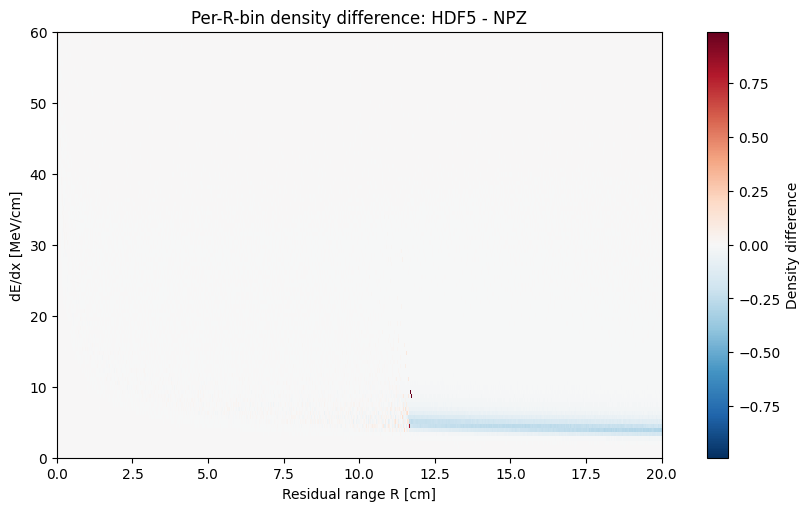

In [2]:
# Row-normalized (per-R-bin) density difference: HDF5-derived minus saved NPZ histogram.
import numpy as np
import matplotlib.pyplot as plt

# Reuse arrays from the previous debug cell if present; otherwise load them here.
try:
    artifact_counts
    h5_counts
    r_edges
    dedx_edges
except NameError:
    npz_path = "/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_proton_dx0.1mm.npz"
    h5_path = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"

    artifact = np.load(npz_path)
    artifact_counts = np.asarray(artifact["counts"], dtype=np.float32)
    r_edges = np.asarray(artifact["r_edges"], dtype=np.float32)
    dedx_key = "dedx_edges" if "dedx_edges" in artifact.files else "dedex_edges"
    dedx_edges = np.asarray(artifact[dedx_key], dtype=np.float32)

    import h5py
    with h5py.File(h5_path, "r") as f:
        seg = f["segments"][:]
    range_h5 = np.asarray(seg["range"], dtype=np.float32)
    dedx_h5 = np.asarray(seg["dEdx"], dtype=np.float32)
    h5_counts, _, _ = np.histogram2d(range_h5, dedx_h5, bins=[r_edges, dedx_edges])

def normalize_per_r_bin(counts_2d):
    # counts_2d shape: (n_r_bins, n_dedx_bins). Normalize each fixed-R slice over dE/dx.
    row_sums = counts_2d.sum(axis=1, keepdims=True)
    return np.divide(
        counts_2d,
        row_sums,
        out=np.zeros_like(counts_2d, dtype=np.float32),
        where=row_sums > 0,
    )

artifact_density = normalize_per_r_bin(np.asarray(artifact_counts, dtype=np.float32))
h5_density = normalize_per_r_bin(np.asarray(h5_counts, dtype=np.float32))
density_diff = h5_density - artifact_density

vmax = float(np.max(np.abs(density_diff)))
if vmax == 0.0:
    vmax = 1.0

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
mesh = ax.pcolormesh(
    r_edges,
    dedx_edges,
    density_diff.T,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
 )
ax.set_xlabel("Residual range R [cm]")
ax.set_ylabel("dE/dx [MeV/cm]")
ax.set_title("Per-R-bin density difference: HDF5 - NPZ")
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("Density difference")

print(f"Max absolute density difference: {vmax:.6e}")
plt.show()